# Comparing malignant cell state across regions proximal and distant to lymphocytes

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

import os

In [5]:
adata = sc.read_h5ad("MH107_setseed_v2.h5ad") 

In [6]:
# Subset data to region of interest, remove areas that are not so great - the bottom right was not imaged well
# Create a boolean mask based on spatial coordinates 
# Subset #1 
x_min = 6400
x_max = 7000
y_min = 1600
y_max = 2800


criteria = (
    (adata.obs['x_centroid'] >= x_min) & (adata.obs['x_centroid'] <= x_max) &
    (adata.obs['y_centroid'] >= y_min) & (adata.obs['y_centroid'] <= y_max)
)

subset_1 = adata[criteria, :] # malignant only

# Subset #2
x_min = 8600
x_max = 9400
y_min = 800
y_max = 2900


criteria = (
    (adata.obs['x_centroid'] >= x_min) & (adata.obs['x_centroid'] <= x_max) &
    (adata.obs['y_centroid'] >= y_min) & (adata.obs['y_centroid'] <= y_max)
)

subset_2 = adata[criteria, :]

In [7]:
malig_only = subset_1[
    (subset_1.obs['cell_class_threshold'] == "Malignant cells") &
    (subset_1.obs['anno'] == "Malignant cells")
].copy()

malig_wTIL = subset_2[
    (subset_2.obs['cell_class_threshold'] == "Malignant cells") &
    (subset_2.obs['anno'] == "Malignant cells")
].copy()

In [8]:
# Ensure X = raw counts before renalysing 
malig_only.X = malig_only.layers['counts'].copy()
malig_wTIL.X = malig_wTIL.layers['counts'].copy() 

In [11]:
# Adding metadata to the adata before combinding them
malig_only.obs["Region"] = "noTIL"
malig_wTIL.obs["Region"] = "wTIL"

import anndata as ad
merged = ad.concat([malig_only, malig_wTIL
                    #, malig_wTIL_2
                   ], merge="same")

## Preprocessing and dimentionality reduction

In [13]:
# Preprocessing
merged.layers["counts"] = merged.X.copy()
sc.pp.normalize_total(merged, inplace=True)
sc.pp.log1p(merged)

# scale the data for visualisation step later
merged.layers['scaled'] = sc.pp.scale(merged, copy=True).X

# Dimentionality reduction
sc.pp.pca(merged, n_comps = 50, random_state=36)
sc.pp.neighbors(merged, n_neighbors = 30, random_state=36)
sc.tl.umap(merged, random_state=36)

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Clustering by leiden, using different resolutions
resolutions = [0.5, 1.0]

for resolution in resolutions:
    key_added = f"leiden_{resolution}"
    sc.tl.leiden(merged, resolution=resolution, key_added=key_added, random_state=36)

In [15]:
merged

AnnData object with n_obs × n_vars = 1720 × 479
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'anno', 'predicted_cell_type_threshold', 'cell_class_threshold', 'Region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'leiden_0.5', 'leiden_1.0'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype 

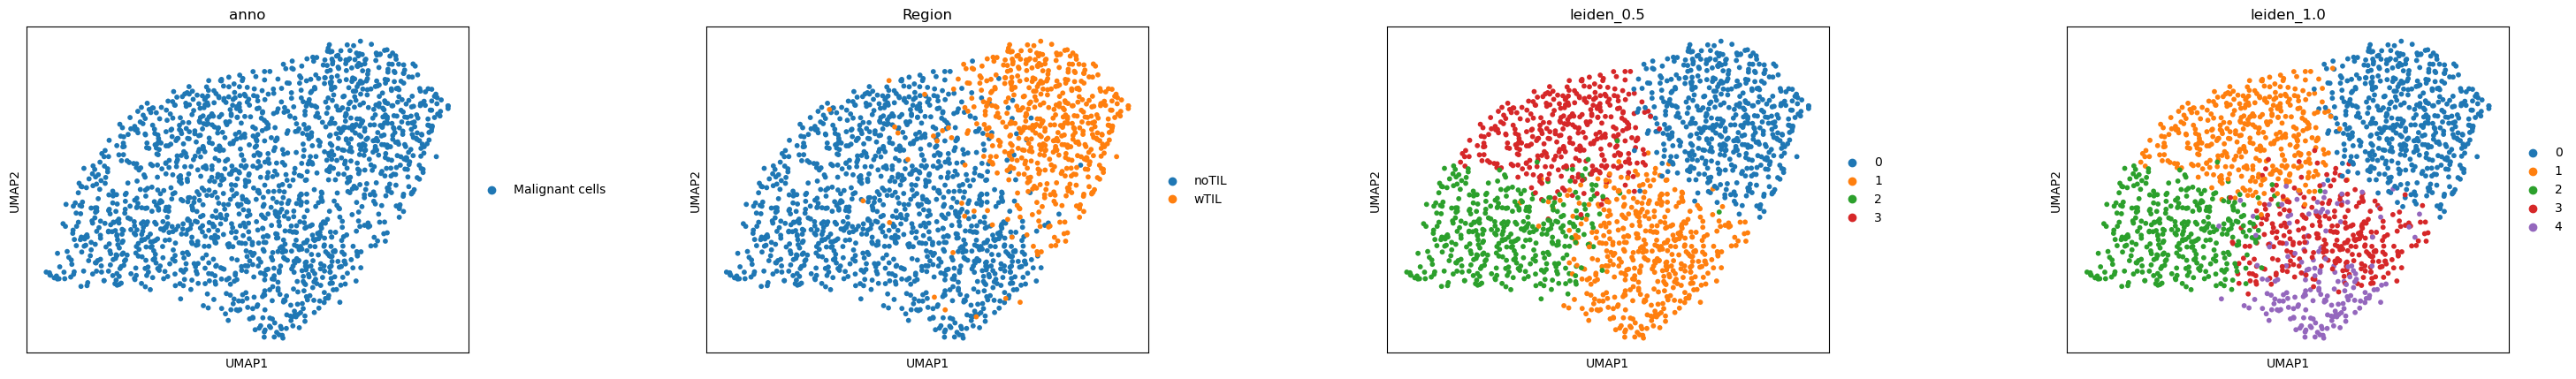

In [16]:
sc.pl.umap(merged, color=['anno','Region','leiden_0.5','leiden_1.0'], wspace = 0.4) #,'leiden_1.5','leiden_1.8','PLA2G2A'])#,'leiden_1.5','leiden_2.0', 'leiden_2.5'])

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


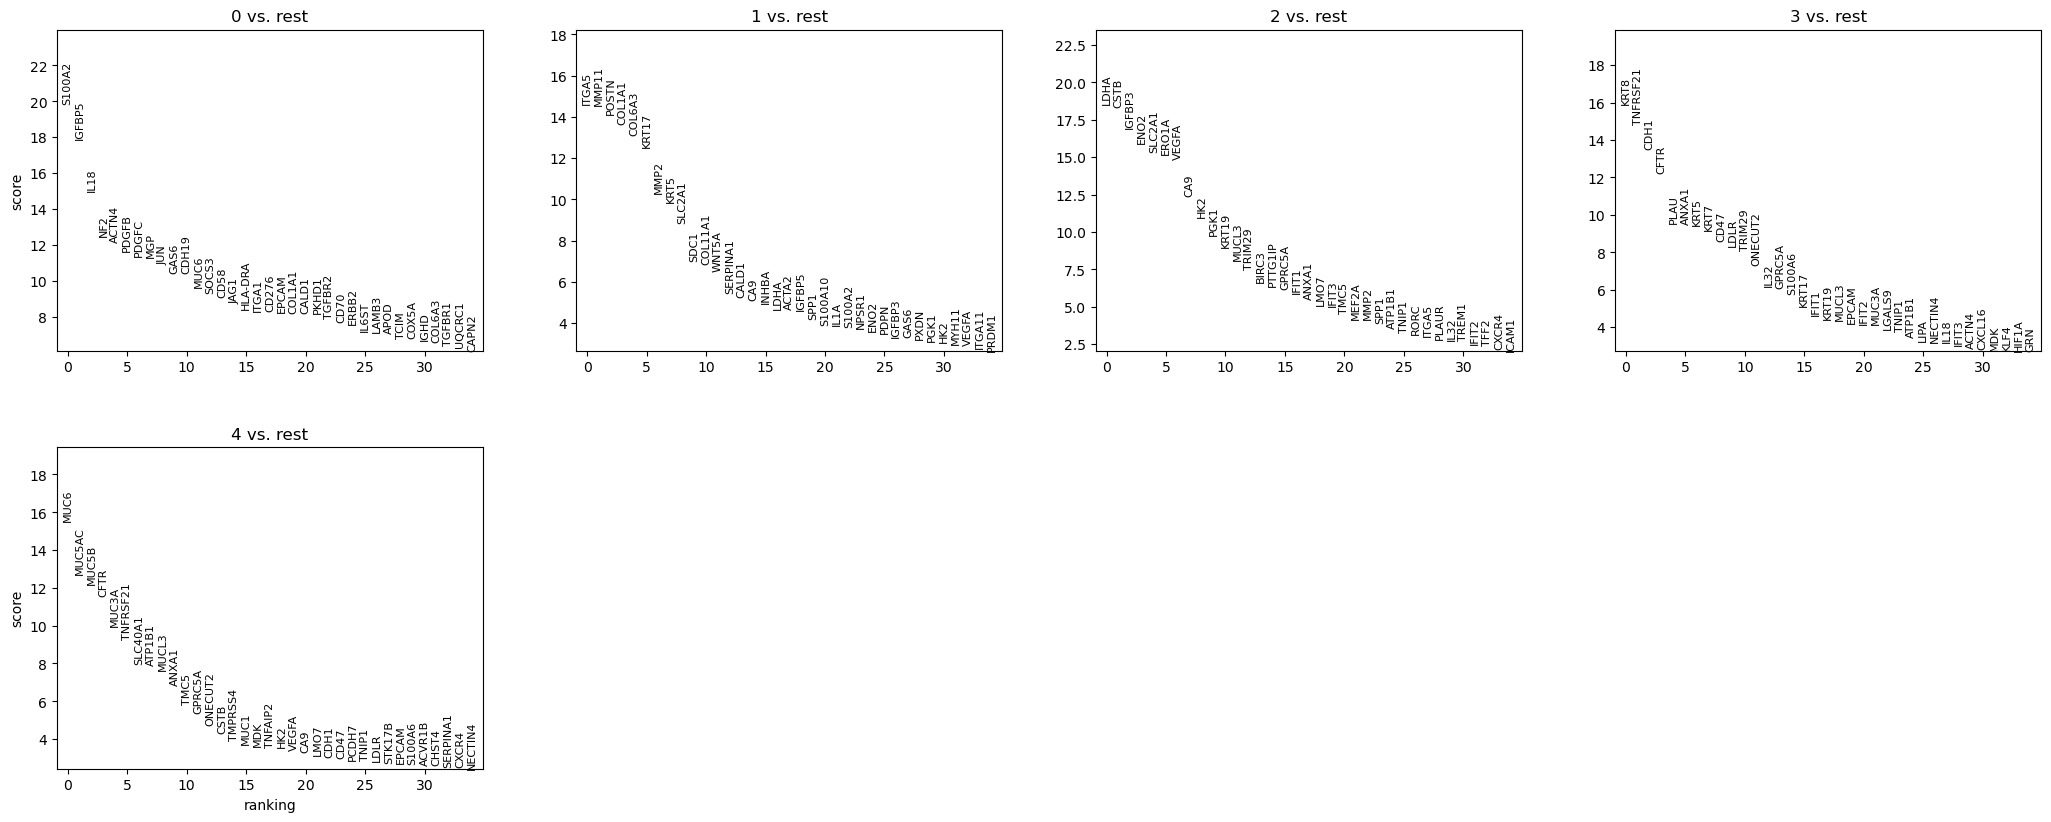

In [17]:
# Find Marker genes
sc.tl.rank_genes_groups(merged, 'leiden_1.0', method='wilcoxon')
sc.pl.rank_genes_groups(merged, n_genes=35, sharey=False)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype 

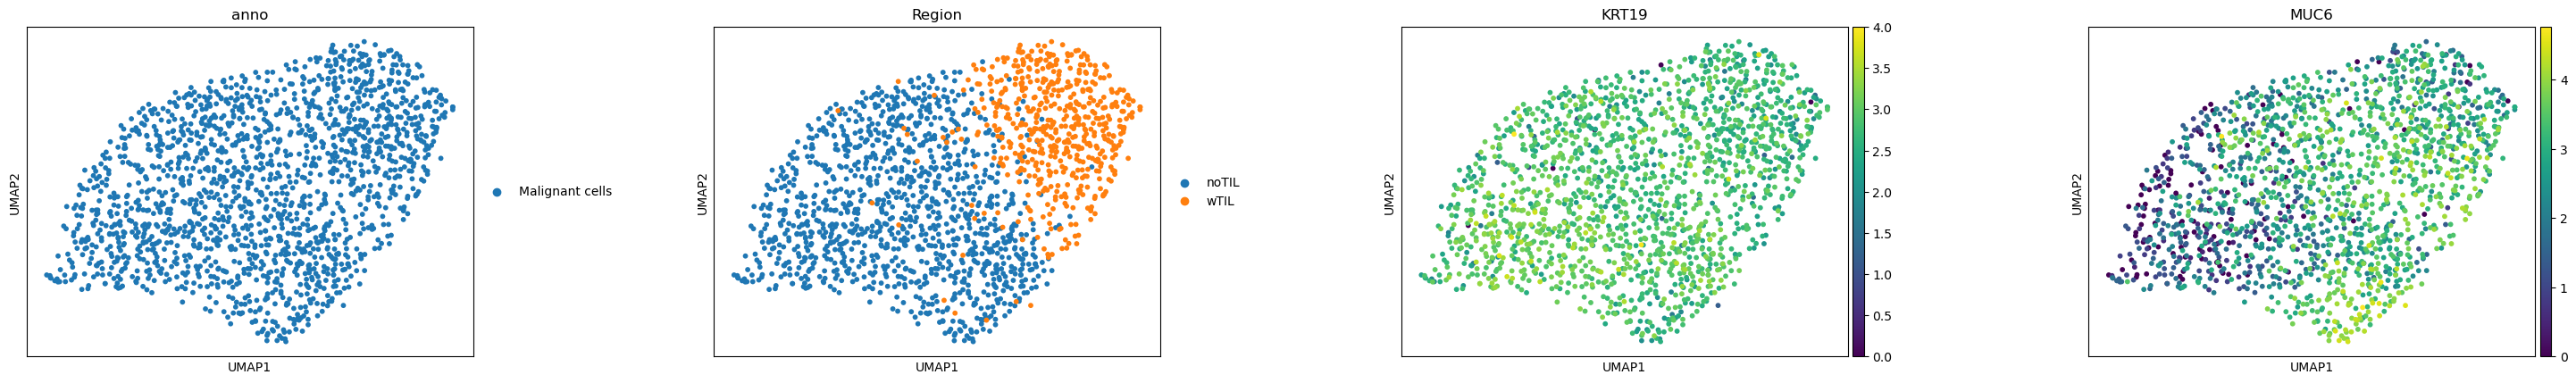

In [18]:
sc.pl.umap(merged, color=['anno','Region','KRT19','MUC6'], wspace = 0.4)

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


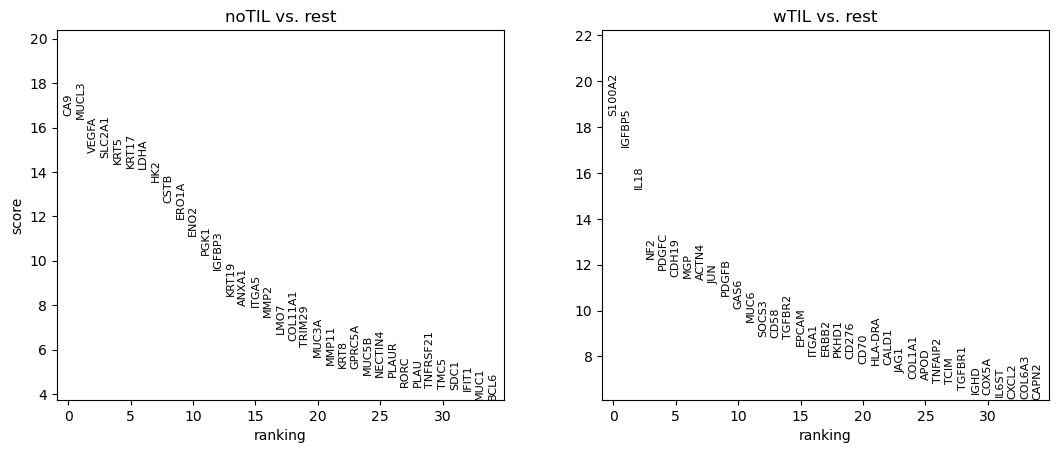

In [19]:
# Find Marker genes
sc.tl.rank_genes_groups(merged, 'Region', method='wilcoxon')
sc.pl.rank_genes_groups(merged, n_genes=35, sharey=False)

In [21]:
result = merged.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(40) # Wilcox-ranked sum test

,noTIL_n,noTIL_p,wTIL_n,wTIL_p
0,CA9,1.741550e-61,S100A2,1.604142e-76
1,MUCL3,2.528249e-60,IGFBP5,7.941586e-66
2,VEGFA,6.639455e-50,IL18,5.389764e-53
3,SLC2A1,1.263204e-48,NF2,1.436745e-34
4,KRT5,9.686561e-47,PDGFC,4.366352e-32
5,KRT17,1.512002e-45,CDH19,1.455973e-30
6,LDHA,2.460277e-45,MGP,2.652039e-30
7,HK2,9.828700e-42,ACTN4,7.717900e-30
8,CSTB,1.413763e-36,JUN,5.652913e-29
9,ERO1A,1.243869e-32,PDGFB,2.179406e-26


In [22]:
features = ['SLC2A1','CA9','LDHA','VEGFA','ERO1A','ENO2','HIF1A','IFIT1','PGK1','PLAU','MUCL3','HK2','KRT5',
            'IL18','NF2','SOCS3','JUN','ERBB2','MUC6','CD276','JAG1','IL6ST','COX5A','TNFAIP2','UQCRC1'
           ] 

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:1067: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if isinstance(groupby, str) and is_categorical_dtype(adata.obs[groupby]):


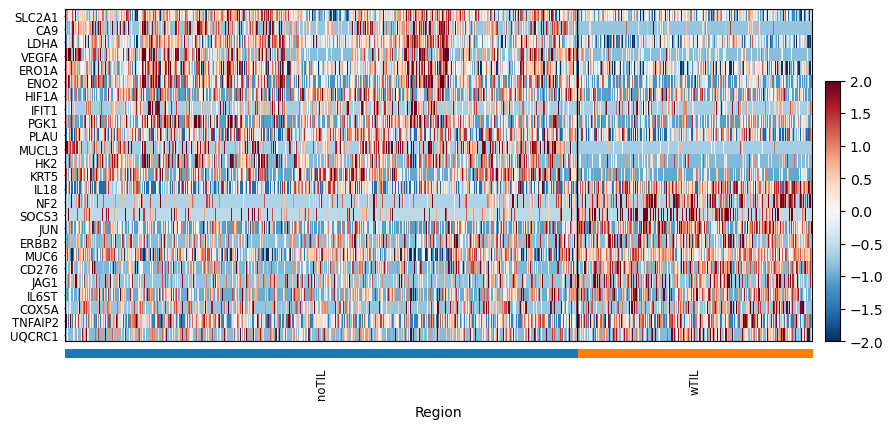

In [23]:
sc.pl.heatmap(
    merged, 
    var_names=features,
    groupby='Region',   
    layer='scaled',  # scale across genes (rows)
    swap_axes=True,
    cmap='RdBu_r',
    vmax = 2,
    vmin = -2
)

## Compute signalling activities in malignant cell

In [24]:
# Load pathway gene sets (e.g., Wnt, TGF-β) derived from multiple sources
# Reference genes from: https://www.nature.com/articles/s41575-019-0109-y
pathway_gene_sets = {
    "NOTCH": ['JAG1','NF2','BCORL1'], #from: https://www.nature.com/articles/s41575-019-0109-y
    "TGFB" : ['SMAD3','SMAD4','TGFBR1','TGFBR2','AVCR1B','ACVR2A'],#from: https://www.nature.com/articles/s41575-019-0109-y
    "IL6":["IL6","IL6R","IL6ST","STAT3","TNFRSF1A","TNFRSF21","JUN","SOCS3"], #checked
    "SQUAMOUS" : ['HK2',"KRT5","GATA6","TP63","TRIM29"], # Bailey et al., 2016
    "TREATMENT" :['IL1A','NRG1','ERBB2','TRAF2'], #Hwang et al.,  treatment-induced changes in malignant cells
    "INFLAMMATORY": ['CCL2','IL1B','NLRP3'], 
    "OXPHOS" : ["NDUFS1","ATP5F1A","ATP1B1","COX5A","UQCRC2","UQCRC1","POR","NDUFV1"],
    "IFNG" : ["CMPK2","DDX60","GBP4","IDO1","IFIT1","IFIT2","IFIT3","ISG15","OASL","RSAD2","ZBP1"],
    "HYPOXIA":["VEGFA","LDHA","SLC2A1","ARNT","ERO1A","HIF1A","CA9"],
    "TNF": ["ABCB1","TRAF1","PIK3CD","TRAF3","CHUK","RIPK1","CASP8","CREB1","TRAF5","TRADD","TNF","TNFRSF1B","MLKL","TNFRSF10B","BIRC2","BIRC3"], 
    "TNF_NFKB" : ["CXCL2","CXCL3","IRF1","LAMB3","NFKB1","NFKB2","NFKBIA","SOD2","PLAU","PLAUR","TNFAIP2","TNFAIP3","TNIP1","TRAF1","BTG2","IFIH1"],
    "WNT": ["WNT6","PTCH1","TCF7","LEF1","AXIN2"],
    "TIGIT":['PVR','NECTIN2','NECTIN3','NECTIN4'],
    "PD1" : ['CD274','PDCD1LG2']
}

In [25]:
# Recompute gene set scores
for pathway, genes in pathway_gene_sets.items():
    sc.tl.score_genes(
        merged,
        gene_list=genes,
        ctrl_size=20,
        random_state=22,
        score_name=f"{pathway}_pathway_score"
    )

# Store pathway scores in a list
pathway_scores = [f"{pathway}_pathway_score" for pathway in pathway_gene_sets.keys()]

# Display scores in the dataset
print(pathway_scores)

['NOTCH_pathway_score', 'TGFB_pathway_score', 'IL6_pathway_score', 'SQUAMOUS_pathway_score', 'TREATMENT_pathway_score', 'INFLAMMATORY_pathway_score', 'OXPHOS_pathway_score', 'IFNG_pathway_score', 'HYPOXIA_pathway_score', 'TNF_pathway_score', 'TNF_NFKB_pathway_score', 'WNT_pathway_score', 'TIGIT_pathway_score', 'PD1_pathway_score']


/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squ

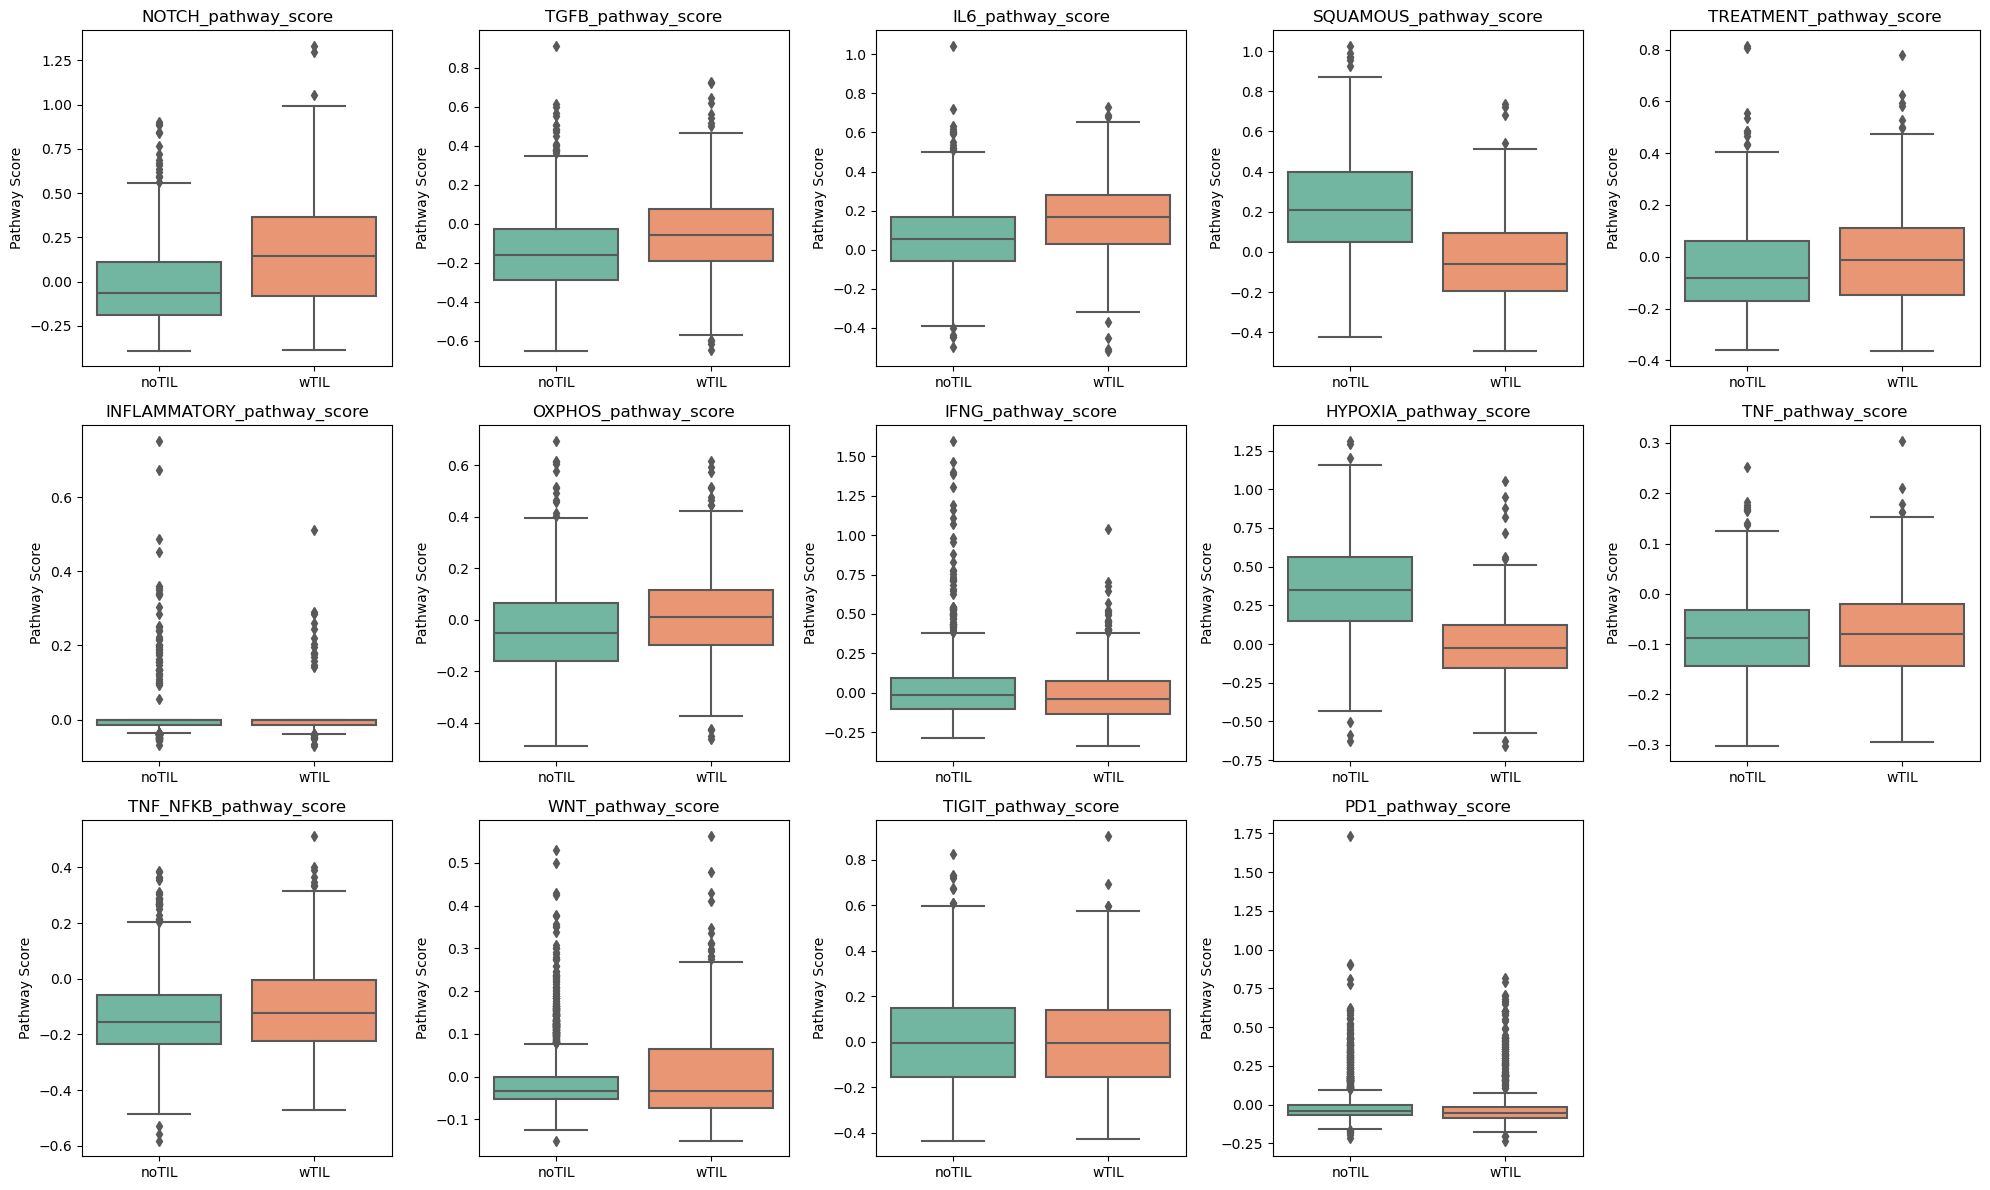

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Number of columns
n_cols = 5
n_rows = math.ceil(len(pathway_scores) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4), squeeze=False)

for i, pathway in enumerate(pathway_scores):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row][col]

    sns.boxplot(
        x="Region", 
        y=pathway, 
        data=merged.obs, 
        palette="Set2", 
        ax=ax
    )
    ax.set_title(f"{pathway}")
    ax.set_xlabel("")  # Optional: clean up
    ax.set_ylabel("Pathway Score")

# Hide unused axes (if any)
total_plots = len(pathway_scores)
for j in range(total_plots, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols][j % n_cols])

plt.tight_layout()
plt.show()

In [28]:
# z-score normalisation
for key in ['NOTCH_pathway_score', 'TGFB_pathway_score', 'IL6_pathway_score', 'SQUAMOUS_pathway_score', 'INFLAMMATORY_pathway_score', 'OXPHOS_pathway_score', 'IFNG_pathway_score', 'HYPOXIA_pathway_score', 'TREATMENT_pathway_score', 'TNF_pathway_score', 'TNF_NFKB_pathway_score', 'WNT_pathway_score', 'TIGIT_pathway_score', 'PD1_pathway_score']:
    vals = merged.obs[key]
    merged.obs[key + "_z"] = (vals - vals.mean()) / vals.std()

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:649: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(color_source_vector):


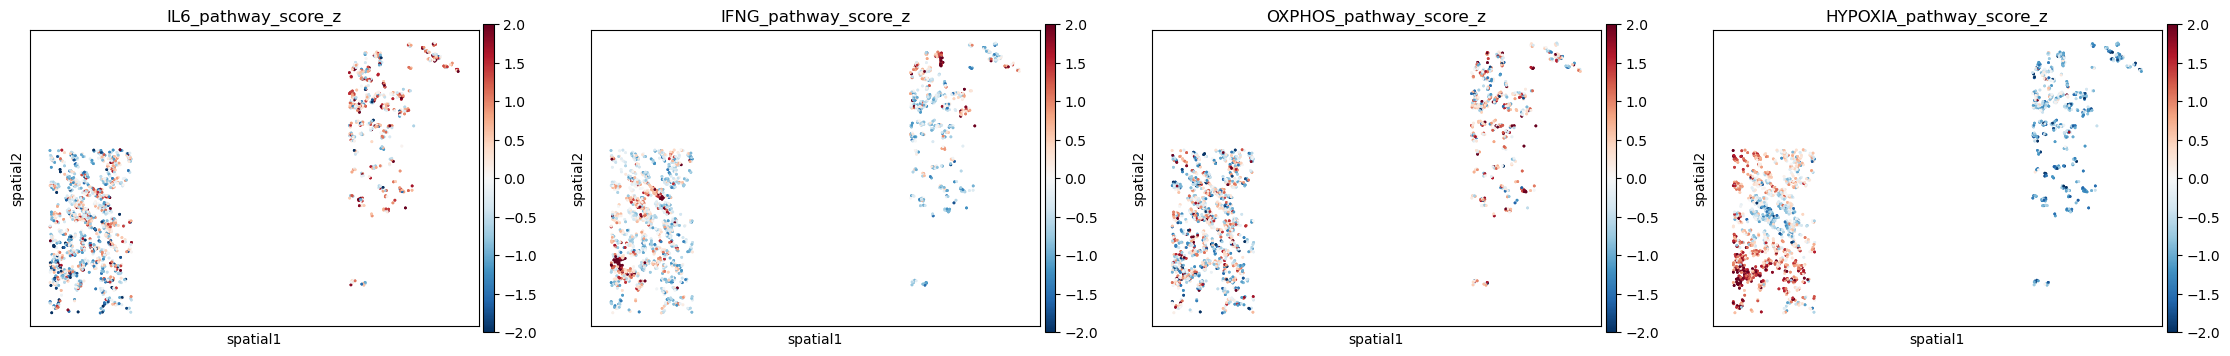

In [34]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    merged,
    library_id="spatial",
    shape=None,
    color=['IL6_pathway_score_z','IFNG_pathway_score_z', 'OXPHOS_pathway_score_z','HYPOXIA_pathway_score_z',
    ],
    #wspace=0.2,
    size=4,
    cmap='RdBu_r',
     vmin=-2, vmax=2,
    figsize = (6, 4)
)